# 2D Likelihood Landscape: Pulsar 0 Distance vs Pulsar 1 Distance

This notebook generates **N** random pulsars and one continuous gravitational
wave (CGW) source, then sweeps the PTA log-likelihood over a 2D grid of:

- **Pulsar 0 distance** (derived from `PX`, in kpc) along the x-axis
- **Pulsar 1 distance** (derived from `PX`, in kpc) along the y-axis

All other pulsars are held at their true (injected) distances.

`PX` is stored as parallax in mas (PINT / `types.py` convention). The sweep
iterates over each pulsar's `PX` in mas; both axes are displayed in kpc via
`d = 1 / PX_mas`. Inside `CWInjector` the same conversion is applied so
the Ellis+2012 pulsar-term phase operates on physical distance.

The CGW pulsar-term phase depends on distance as
$$
\phi_p \;=\; \phi_e \;-\; 2\pi f_{gw}\,\frac{d}{c}\,(1 + \cos\mu),
$$
so the likelihood contribution from each pulsar is periodic in that pulsar's
distance, with period $\Delta d = c / [f_{gw}(1+\cos\mu)]$ set by its own
opening angle $\mu$ relative to the CGW source. The 2D landscape should
therefore show a lattice of Gaussian peaks at the phase-matching degeneracies.

In [1]:
%matplotlib widget
import matplotlib.pyplot as plt

In [ ]:
from __future__ import annotations

from loguru import logger
logger.disable("pint")

from io import StringIO

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

import pint.models as pm

from jaxpint.pta.likelihood import pta_logL
from jaxpint.pta.signals.cw import CWInjectorStack
from jaxpint.notebook_utils import (
    pulsar_positions_from_models,
    generate_random_par,
    inject_and_build_config,
    plot_2d_delta_logL,
    setup_synthetic_pta,
    sweep_2d_logL,
)

# ---- Configuration ----
N_PULSARS = 10
M_CW_SOURCES = 10
N_TOAS = 200
START_MJD = 57000.0
END_MJD = 60000.0       # ~8 yr observation span
TOA_ERROR = 1e-8         # 10 ns
FREQ = 1400.0            # MHz
SEED = 42


## Generate random pulsars

Each pulsar gets a random sky position, spin frequency, spindown rate, and
distance. The par file includes spindown (F0, F1), astrometry (RAJ, DECJ, PX),
and unscaled white noise (EFAC = 1).

In [3]:
rng = np.random.default_rng(SEED)

par_strings = [generate_random_par(idx, rng, start_mjd=START_MJD) for idx in range(N_PULSARS)]
pint_models = [pm.get_model(StringIO(p)) for p in par_strings]

print(f"Generated {N_PULSARS} pulsars")
print(f"Example .par:\n{par_strings[0]}")


Generated 10 pulsars
Example .par:
PSR           J1834-0701_00
RAJ           18:34:29.80260
DECJ          -07:01:17.6778
F0            443.4391679646
F1            -2.481624e-15
PEPOCH        57000.0
PX            1.359724
EPHEM         DE440
CLK           TT(BIPM2019)
UNITS         TDB
EFAC tel gbt 1.0



## Generate fake TOAs and convert to JaxPINT

In [4]:
synthetic = setup_synthetic_pta(
    pint_models,
    start_mjd=START_MJD, end_mjd=END_MJD,
    n_toas=N_TOAS, toa_error_s=TOA_ERROR, freq_mhz=FREQ,
)
pulsar_params_list = list(synthetic.pulsar_params_list)
timing_models = list(synthetic.timing_models)
noise_models = list(synthetic.noise_models)
pp_tuple = synthetic.pulsar_params_list

for i, model in enumerate(pint_models):
    px_mas = float(pulsar_params_list[i].param_value("PX"))
    distance_kpc = 1.0 / px_mas
    f0 = float(pulsar_params_list[i].param_value("F0"))
    print(
        f"  Pulsar {i}: {model.PSR.value:>20s}  "
        f"PX={px_mas:.3f} mas (d={distance_kpc:.2f} kpc)  F0={f0:.1f} Hz"
    )

print(f"\nAll {N_PULSARS} pulsars loaded.")

/home/hector/NYU/PTA/jax_pint/JaxPINT/.venv/lib/python3.12/site-packages/pint/observatory/clock_file.py:183: UserWarning: Data points out of range in clock file 'tai2tt_bipm2019.clk'
  warn(msg)
/home/hector/NYU/PTA/jax_pint/JaxPINT/.venv/lib/python3.12/site-packages/pint/observatory/clock_file.py:183: UserWarning: Data points out of range in clock file 'tai2tt_bipm2019.clk'
  warn(msg)


  Pulsar 0:        J1834-0701_00  PX=1.360 mas (d=0.74 kpc)  F0=443.4 Hz
  Pulsar 1:        J2324+3129_01  PX=0.615 mas (d=1.63 kpc)  F0=414.4 Hz
  Pulsar 2:        J0853+5835_02  PX=0.622 mas (d=1.61 kpc)  F0=357.5 Hz
  Pulsar 3:        J0527+0616_03  PX=0.481 mas (d=2.08 kpc)  F0=125.5 Hz
  Pulsar 4:        J1811-1654_04  PX=0.409 mas (d=2.45 kpc)  F0=488.3 Hz
  Pulsar 5:        J0440-0348_05  PX=0.453 mas (d=2.21 kpc)  F0=117.5 Hz
  Pulsar 6:        J1752+6913_06  PX=0.597 mas (d=1.67 kpc)  F0=230.3 Hz
  Pulsar 7:        J0432-4744_07  PX=0.460 mas (d=2.17 kpc)  F0=290.3 Hz
  Pulsar 8:        J1029+4142_08  PX=0.387 mas (d=2.58 kpc)  F0=380.1 Hz
  Pulsar 9:        J1918-1300_09  PX=1.177 mas (d=0.85 kpc)  F0=215.3 Hz

All 10 pulsars loaded.


## Set up the CW source and inject into TOAs

We place a single continuous gravitational wave source at a random sky
location with a random nHz-band GW frequency and strain $h = 10^{-14}$.

In [ ]:
# Pulsar unit vectors for CWInjectorStack
positions = pulsar_positions_from_models(pint_models)

TRUE_LOG10_H = -14.0

per_source_values = [
    {
        "log10_h": TRUE_LOG10_H,
        "cos_gwtheta": float(rng.uniform(-1, 1)),
        "gwphi": float(rng.uniform(0, 2 * np.pi)),
        "log10_fgw": float(rng.uniform(-9, -7)),
    }
    for _ in range(M_CW_SOURCES)
]

cw_injector = CWInjectorStack(
    positions, n_sources=M_CW_SOURCES, per_source_values=per_source_values,
)

gp, config = inject_and_build_config(synthetic, (cw_injector,))

print(f"PTA config built with {M_CW_SOURCES} CW sources (single vmapped injector).")
print(f"Global params: {gp.n_params} total")


## 2D likelihood sweep: pulsar 0 distance vs pulsar 1 distance

We sweep `PX` of pulsar 0 (x-axis) against `PX` of pulsar 1 (y-axis), holding
all other parameters (global CW params and all other pulsars' PX) fixed at
their true injected values. The evaluation is a nested `jax.vmap` over both
axes, wrapped in a single `jax.jit`, so the 500&times;500 = 250k-point grid
compiles once and runs fully vectorized.

In [6]:
# Window sized so peaks (~2e-3 pc FWHM at log10_h=-14, N_TOAS=200, sigma_TOA=1e-8)
# span ~2 pixels and ~6 periods of the pulsar-term degeneracy are visible per axis.
# Pulsar-0 period is c / [f_gw (1+cos mu)] ~ 0.3 pc for this seed's CW source.
HALF_WINDOW_KPC_X = 1e-3   # +/- 2 pc (~6 periods along pulsar 0)
N_GRID_X = 3000            # step ~1.3e-3 pc, ~2 pixels per peak FWHM

HALF_WINDOW_KPC_Y = 1e-3
N_GRID_Y = 3000

PULSAR_A, PULSAR_B = 0, 1

In [7]:
true_px_a_mas = float(pulsar_params_list[PULSAR_A].param_value("PX"))
true_px_b_mas = float(pulsar_params_list[PULSAR_B].param_value("PX"))
true_dist_a = 1.0 / true_px_a_mas
true_dist_b = 1.0 / true_px_b_mas
print(f"Pulsar {PULSAR_A} true distance: {true_dist_a:.3f} kpc "
      f"(PX = {true_px_a_mas:.4f} mas)")
print(f"Pulsar {PULSAR_B} true distance: {true_dist_b:.3f} kpc "
      f"(PX = {true_px_b_mas:.4f} mas)")

# Build both grids in kpc for the plot axes, then invert to mas for the sweep.
dist_a_grid = np.linspace(true_dist_a - HALF_WINDOW_KPC_X,
                          true_dist_a + HALF_WINDOW_KPC_X, N_GRID_X)
dist_b_grid = np.linspace(true_dist_b - HALF_WINDOW_KPC_Y,
                          true_dist_b + HALF_WINDOW_KPC_Y, N_GRID_Y)
px_a_mas_grid = 1.0 / dist_a_grid
px_b_mas_grid = 1.0 / dist_b_grid

def eval_logL_2d(px_a_mas, px_b_mas):
    pp_a = pp_tuple[PULSAR_A].with_value("PX", px_a_mas)
    pp_b = pp_tuple[PULSAR_B].with_value("PX", px_b_mas)
    pp_mod = (pp_a, pp_b) + pp_tuple[2:]
    return pta_logL(gp, pp_mod, config)

print(f"Computing {N_GRID_X} x {N_GRID_Y} = {N_GRID_X * N_GRID_Y} "
      f"likelihood evaluations...")
logL_2d = sweep_2d_logL(eval_logL_2d, px_a_mas_grid, px_b_mas_grid)
print("Done.")

Pulsar 0 true distance: 0.735 kpc (PX = 1.3597 mas)
Pulsar 1 true distance: 1.626 kpc (PX = 0.6150 mas)
Computing 3000 x 3000 = 9000000 likelihood evaluations...
Done.


## 2D pcolormesh plot

The red star marks the true injected (d&#8320;, d&#8321;). Expect a bright
central peak plus a 2D lattice of secondary peaks at the phase-matching
degeneracies. The peak spacings along each axis depend on that pulsar's
opening angle $\mu$ to the CW source, so the two axes generally have
different periodicities.

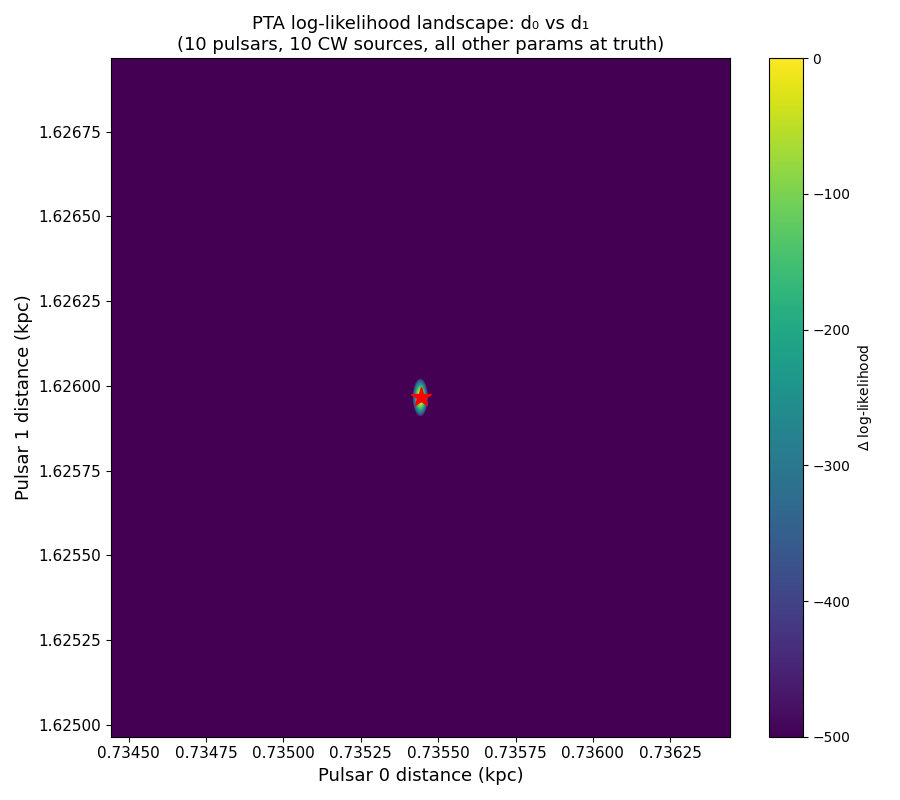

In [8]:
fig, ax = plt.subplots(figsize=(9, 8))

# logL_2d is indexed by (px_b_mas_grid, px_a_mas_grid) in sweep order. Since
# distance = 1 / PX is monotonically decreasing, reverse both axes to present
# the plot in ascending kpc.
dist_a_plot = dist_a_grid[::-1]
dist_b_plot = dist_b_grid[::-1]
logL_2d_plot = logL_2d[::-1, ::-1]

mesh = plot_2d_delta_logL(
    ax, dist_a_plot, dist_b_plot, logL_2d_plot,
)

ax.plot(true_dist_a, true_dist_b, "r*", markersize=15, label="True values")

ax.set_xlabel(f"Pulsar {PULSAR_A} distance (kpc)", fontsize=13)
ax.set_ylabel(f"Pulsar {PULSAR_B} distance (kpc)", fontsize=13)
ax.set_title(
    f"PTA log-likelihood landscape: d₀ vs d₁\n"
    f"({N_PULSARS} pulsars, {M_CW_SOURCES} CW sources, all other params at truth)",
    fontsize=13,
)
ax.tick_params(labelsize=11)
fig.colorbar(mesh, ax=ax, label=r"$\Delta$ log-likelihood")
fig.tight_layout()
plt.show()

## 1D projections along each pulsar distance

Slices through `logL_2d` at the other pulsar's true distance (conditional likelihood, matching the 2D plot's "all other params at truth" convention).

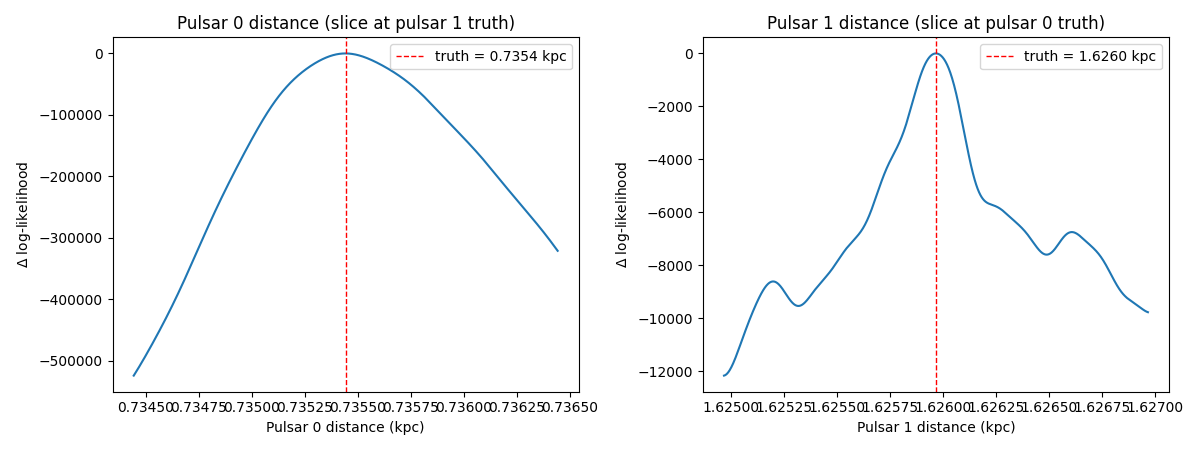

In [9]:
# Slice 2D grid at the true distance of the other pulsar. The sweep grids are
# in mas (monotonically decreasing in kpc), so index against px_*_mas_grid.
idx_b_true = int(np.argmin(np.abs(np.asarray(px_b_mas_grid) - true_px_b_mas)))
idx_a_true = int(np.argmin(np.abs(np.asarray(px_a_mas_grid) - true_px_a_mas)))

logL_1d_a = logL_2d[idx_b_true, :]           # vs pulsar A distance
logL_1d_b = logL_2d[:, idx_a_true]           # vs pulsar B distance

delta_a = logL_1d_a - logL_1d_a.max()
delta_b = logL_1d_b - logL_1d_b.max()

# Present on a kpc axis: reverse to match ascending kpc order.
dist_a_plot = np.asarray(dist_a_grid)[::-1]
dist_b_plot = np.asarray(dist_b_grid)[::-1]
delta_a_plot = delta_a[::-1]
delta_b_plot = delta_b[::-1]

fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(12, 4.5))

ax0.plot(dist_a_plot, delta_a_plot, lw=1.5)
ax0.axvline(true_dist_a, color="r", ls="--", lw=1, label=f"truth = {true_dist_a:.4f} kpc")
ax0.set_xlabel(f"Pulsar {PULSAR_A} distance (kpc)")
ax0.set_ylabel(r"$\Delta$ log-likelihood")
ax0.set_title(f"Pulsar {PULSAR_A} distance (slice at pulsar {PULSAR_B} truth)")
ax0.legend()

ax1.plot(dist_b_plot, delta_b_plot, lw=1.5)
ax1.axvline(true_dist_b, color="r", ls="--", lw=1, label=f"truth = {true_dist_b:.4f} kpc")
ax1.set_xlabel(f"Pulsar {PULSAR_B} distance (kpc)")
ax1.set_ylabel(r"$\Delta$ log-likelihood")
ax1.set_title(f"Pulsar {PULSAR_B} distance (slice at pulsar {PULSAR_A} truth)")
ax1.legend()

fig.tight_layout()
plt.show()